สร้างไฟล์ GWO_Manual_Calculation.md สำหรับโชว์วิธีคำนวณมือ 2 รอบเรียบร้อยแล้ว!

กำลังคำนวณ GWO 30 Runs เพื่อหา Metrics (เริ่มที่ x=1, y=1)...

=== ผลลัพธ์สำหรับ Rosenbrock Function ===
Best Fitness  : 0.0000000000
Mean Fitness  : 0.0000000000
Worst Fitness : 0.0000000000
Std Deviation : 0.0000000000
Avg Runtime   : 0.028534 วินาที

=== ผลลัพธ์สำหรับ Rastrigin Function ===
Best Fitness  : 0.0000000000
Mean Fitness  : 0.2363673652
Worst Fitness : 1.9919244925
Std Deviation : 0.4927306323
Avg Runtime   : 0.034113 วินาที


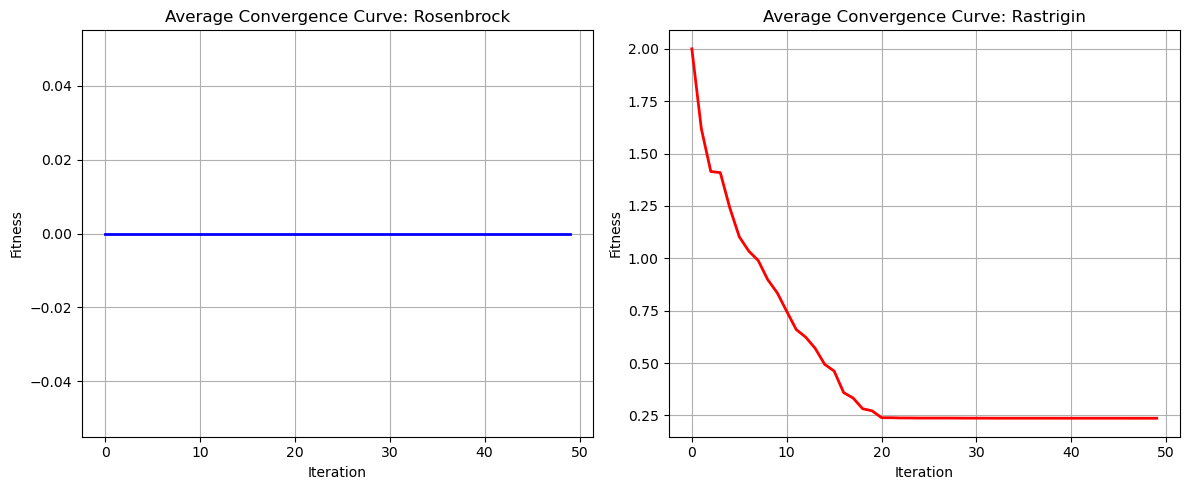

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ==========================================
# 1. นิยามฟังก์ชันเป้าหมาย
# ==========================================
def rosenbrock(pos):
    x, y = pos[0], pos[1]
    return (1 - x)**2 + 100 * (y - x**2)**2

def rastrigin(pos):
    x, y = pos[0], pos[1]
    return 20 + x**2 + y**2 - 10 * (np.cos(2 * np.pi * x) + np.cos(2 * np.pi * y))

# ==========================================
# 2. ฟังก์ชันสร้างไฟล์ Markdown แสดงการคำนวณมือ (2 Iterations)
# ==========================================
def generate_manual_calc_md(filename):
    np.random.seed(42) # ล็อก Seed ให้ตัวเลขคงที่สำหรับพรีเซนต์
    dim = 2
    num_wolves = 3 # ใช้ 3 ตัวเพื่อให้ไฟล์คำนวณมือไม่อ่านยากจนเกินไป
    max_iter = 2
    
    funcs = [("Rosenbrock", rosenbrock), ("Rastrigin", rastrigin)]
    
    with open(filename, 'w', encoding='utf-8') as f:
        f.write("# แสดงการคำนวณมือ GWO (Manual Calculation)\n\n")
        f.write(f"**จำนวนหมาป่า:** {num_wolves} ตัว  \n")
        f.write(f"**จุดเริ่มต้น:** x=1, y=1 ทุกตัว  \n")
        f.write(f"**จำนวนรอบ:** {max_iter} Iterations\n\n")
        f.write("---\n\n")
        
        for func_name, obj_func in funcs:
            f.write(f"## ฟังก์ชัน: {func_name}\n\n")
            
            # กำหนดจุดเริ่มต้น x=1, y=1
            positions = np.ones((num_wolves, dim))
            
            alpha_pos, alpha_score = np.zeros(dim), float("inf")
            beta_pos, beta_score = np.zeros(dim), float("inf")
            delta_pos, delta_score = np.zeros(dim), float("inf")
            
            for l in range(max_iter):
                f.write(f"### Iteration ที่ {l + 1}\n\n")
                f.write("#### 1. คำนวณ Fitness และจัดลำดับผู้นำ (Alpha, Beta, Delta)\n")
                
                for i in range(num_wolves):
                    fitness = obj_func(positions[i, :])
                    f.write(f"- **หมาป่าตัวที่ {i+1}:** ตำแหน่ง [{positions[i,0]:.4f}, {positions[i,1]:.4f}] -> Fitness = {fitness:.4f}\n")
                    
                    if fitness < alpha_score:
                        delta_score, delta_pos = beta_score, beta_pos.copy()
                        beta_score, beta_pos = alpha_score, alpha_pos.copy()
                        alpha_score, alpha_pos = fitness, positions[i, :].copy()
                    elif fitness < beta_score and fitness > alpha_score:
                        delta_score, delta_pos = beta_score, beta_pos.copy()
                        beta_score, beta_pos = fitness, positions[i, :].copy()
                    elif fitness < delta_score and fitness > beta_score and fitness > alpha_score:
                        delta_score, delta_pos = fitness, positions[i, :].copy()
                        
                f.write("\n**สรุปผู้นำรอบนี้:**\n")
                f.write(f"- จ่าฝูง (Alpha): ตำแหน่ง [{alpha_pos[0]:.4f}, {alpha_pos[1]:.4f}] (Fitness: {alpha_score:.4f})\n")
                f.write(f"- รองจ่าฝูง (Beta): ตำแหน่ง [{beta_pos[0]:.4f}, {beta_pos[1]:.4f}] (Fitness: {beta_score:.4f})\n")
                f.write(f"- ผู้ตาม (Delta): ตำแหน่ง [{delta_pos[0]:.4f}, {delta_pos[1]:.4f}] (Fitness: {delta_score:.4f})\n\n")
                
                # สมการปรับค่าพารามิเตอร์ a ให้ลดลงเชิงเส้นจาก 2 ไป 0
                a = 2 - l * (2 / 50) # สมมติใช้ MaxIter จริงที่ 50 ในการคำนวณค่า a
                f.write(f"#### 2. คำนวณพารามิเตอร์ a\n")
                f.write(f"- ค่า `a` ลดลงเชิงเส้นจาก 2 ถึง 0 (อิง MaxIter=50) -> **a = {a:.4f}**\n\n")
                
                f.write("#### 3. อัปเดตตำแหน่งของหมาป่าแต่ละตัว\n")
                for i in range(num_wolves):
                    f.write(f"**หมาป่าตัวที่ {i+1} (ตำแหน่งเดิม [{positions[i,0]:.4f}, {positions[i,1]:.4f}]):**\n\n")
                    new_pos = np.zeros(dim)
                    
                    for j in range(dim):
                        var_name = 'x' if j == 0 else 'y'
                        
                        # Alpha
                        r1, r2 = np.random.rand(), np.random.rand()
                        # สมการคำนวณสัมประสิทธิ์เวกเตอร์ A และ C: A = 2*a*r1 - a, C = 2*r2
                        A1, C1 = 2 * a * r1 - a, 2 * r2
                        # สมการระยะห่างระหว่างหมาป่ากับ Alpha (D_alpha)
                        D_alpha = abs(C1 * alpha_pos[j] - positions[i, j])
                        # สมการทิศทางการขยับตัวเทียบกับ Alpha (X1)
                        X1 = alpha_pos[j] - A1 * D_alpha
                        
                        # Beta
                        r1, r2 = np.random.rand(), np.random.rand()
                        # สมการคำนวณสัมประสิทธิ์เวกเตอร์ A และ C สำหรับ Beta
                        A2, C2 = 2 * a * r1 - a, 2 * r2
                        # สมการระยะห่างระหว่างหมาป่ากับ Beta (D_beta)
                        D_beta = abs(C2 * beta_pos[j] - positions[i, j])
                        # สมการทิศทางการขยับตัวเทียบกับ Beta (X2)
                        X2 = beta_pos[j] - A2 * D_beta
                        
                        # Delta
                        r1, r2 = np.random.rand(), np.random.rand()
                        # สมการคำนวณสัมประสิทธิ์เวกเตอร์ A และ C สำหรับ Delta
                        A3, C3 = 2 * a * r1 - a, 2 * r2
                        # สมการระยะห่างระหว่างหมาป่ากับ Delta (D_delta)
                        D_delta = abs(C3 * delta_pos[j] - positions[i, j])
                        # สมการทิศทางการขยับตัวเทียบกับ Delta (X3)
                        X3 = delta_pos[j] - A3 * D_delta
                        
                        # สมการอัปเดตตำแหน่งใหม่ (หาค่าเฉลี่ยทิศทางจากผู้นำทั้งสาม)
                        new_pos[j] = (X1 + X2 + X3) / 3
                        
                        f.write(f"- **แกน {var_name}:**\n")
                        f.write(f"  - เทียบ Alpha: A1={A1:.4f}, C1={C1:.4f}, D_alpha={D_alpha:.4f} -> **X1={X1:.4f}**\n")
                        f.write(f"  - เทียบ Beta: A2={A2:.4f}, C2={C2:.4f}, D_beta={D_beta:.4f} -> **X2={X2:.4f}**\n")
                        f.write(f"  - เทียบ Delta: A3={A3:.4f}, C3={C3:.4f}, D_delta={D_delta:.4f} -> **X3={X3:.4f}**\n")
                        f.write(f"  - ค่าเฉลี่ยตำแหน่งใหม่ = (X1 + X2 + X3) / 3 = **{new_pos[j]:.4f}**\n\n")
                        
                    positions[i, :] = new_pos
                    f.write(f"> **สรุปตำแหน่งใหม่หมาป่าตัวที่ {i+1} = [{positions[i,0]:.4f}, {positions[i,1]:.4f}]**\n\n")
            f.write("---\n\n")
            
    print(f"สร้างไฟล์ {filename} สำหรับโชว์วิธีคำนวณมือ 2 รอบเรียบร้อยแล้ว!")

# ==========================================
# 3. ฟังก์ชันรันประเมินผลเพื่อเก็บ Metrics (30 Runs)
# ==========================================
def run_gwo_evaluation(obj_func, dim=2, num_wolves=30, max_iter=50, num_runs=30):
    best_scores_all_runs = []
    runtimes = []
    all_convergence_curves = np.zeros((num_runs, max_iter))

    for run in range(num_runs):
        start_time = time.time()
        positions = np.ones((num_wolves, dim))
        
        alpha_pos, alpha_score = np.zeros(dim), float("inf")
        beta_pos, beta_score = np.zeros(dim), float("inf")
        delta_pos, delta_score = np.zeros(dim), float("inf")

        convergence_curve = np.zeros(max_iter)

        for l in range(max_iter):
            for i in range(num_wolves):
                fitness = obj_func(positions[i, :])

                if fitness < alpha_score:
                    delta_score, delta_pos = beta_score, beta_pos.copy()
                    beta_score, beta_pos = alpha_score, alpha_pos.copy()
                    alpha_score, alpha_pos = fitness, positions[i, :].copy()
                elif fitness < beta_score and fitness > alpha_score:
                    delta_score, delta_pos = beta_score, beta_pos.copy()
                    beta_score, beta_pos = fitness, positions[i, :].copy()
                elif fitness < delta_score and fitness > beta_score and fitness > alpha_score:
                    delta_score, delta_pos = fitness, positions[i, :].copy()

            # สมการปรับค่าพารามิเตอร์ a ให้ลดลงเชิงเส้นจาก 2 ไป 0 ตามจำนวน Iteration
            a = 2 - l * (2 / max_iter)

            for i in range(num_wolves):
                for j in range(dim):
                    r1, r2 = np.random.rand(), np.random.rand()
                    # สมการคำนวณสัมประสิทธิ์ A และ C
                    A1, C1 = 2 * a * r1 - a, 2 * r2
                    # สมการระยะห่างการล้อมเหยื่อเทียบกับ Alpha
                    D_alpha = abs(C1 * alpha_pos[j] - positions[i, j])
                    # สมการประเมินทิศทางเข้าหาเหยื่อจากตำแหน่ง Alpha
                    X1 = alpha_pos[j] - A1 * D_alpha

                    r1, r2 = np.random.rand(), np.random.rand()
                    # สมการคำนวณสัมประสิทธิ์ A และ C
                    A2, C2 = 2 * a * r1 - a, 2 * r2
                    # สมการระยะห่างการล้อมเหยื่อเทียบกับ Beta
                    D_beta = abs(C2 * beta_pos[j] - positions[i, j])
                    # สมการประเมินทิศทางเข้าหาเหยื่อจากตำแหน่ง Beta
                    X2 = beta_pos[j] - A2 * D_beta

                    r1, r2 = np.random.rand(), np.random.rand()
                    # สมการคำนวณสัมประสิทธิ์ A และ C
                    A3, C3 = 2 * a * r1 - a, 2 * r2
                    # สมการระยะห่างการล้อมเหยื่อเทียบกับ Delta
                    D_delta = abs(C3 * delta_pos[j] - positions[i, j])
                    # สมการประเมินทิศทางเข้าหาเหยื่อจากตำแหน่ง Delta
                    X3 = delta_pos[j] - A3 * D_delta

                    # สมการอัปเดตตำแหน่งใหม่ของหมาป่า (ค่าเฉลี่ยจาก 3 ผู้นำ)
                    positions[i, j] = (X1 + X2 + X3) / 3

            convergence_curve[l] = alpha_score
            
        runtimes.append(time.time() - start_time)
        best_scores_all_runs.append(alpha_score)
        all_convergence_curves[run, :] = convergence_curve

    metrics = {
        "Best": np.min(best_scores_all_runs),
        "Mean": np.mean(best_scores_all_runs),
        "Worst": np.max(best_scores_all_runs),
        "Std": np.std(best_scores_all_runs),
        "Avg_Runtime": np.mean(runtimes),
        "Avg_Curve": np.mean(all_convergence_curves, axis=0)
    }
    return metrics

# --- สั่งรันโปรแกรมหลัก ---
if __name__ == "__main__":
    # 1. สร้างไฟล์ Markdown
    generate_manual_calc_md("GWO_Manual_Calculation.md")

    # 2. คำนวณ Metrics เชิงลึก
    np.random.seed(42)
    print("\nกำลังคำนวณ GWO 30 Runs เพื่อหา Metrics (เริ่มที่ x=1, y=1)...")
    res_rosen = run_gwo_evaluation(rosenbrock)
    res_rast = run_gwo_evaluation(rastrigin)

    print("\n=== ผลลัพธ์สำหรับ Rosenbrock Function ===")
    print(f"Best Fitness  : {res_rosen['Best']:.10f}")
    print(f"Mean Fitness  : {res_rosen['Mean']:.10f}")
    print(f"Worst Fitness : {res_rosen['Worst']:.10f}")
    print(f"Std Deviation : {res_rosen['Std']:.10f}")
    print(f"Avg Runtime   : {res_rosen['Avg_Runtime']:.6f} วินาที")

    print("\n=== ผลลัพธ์สำหรับ Rastrigin Function ===")
    print(f"Best Fitness  : {res_rast['Best']:.10f}")
    print(f"Mean Fitness  : {res_rast['Mean']:.10f}")
    print(f"Worst Fitness : {res_rast['Worst']:.10f}")
    print(f"Std Deviation : {res_rast['Std']:.10f}")
    print(f"Avg Runtime   : {res_rast['Avg_Runtime']:.6f} วินาที")

    # 3. พลอตกราฟ
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(res_rosen['Avg_Curve'], color='blue', linewidth=2)
    plt.title('Average Convergence Curve: Rosenbrock')
    plt.xlabel('Iteration')
    plt.ylabel('Fitness')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(res_rast['Avg_Curve'], color='red', linewidth=2)
    plt.title('Average Convergence Curve: Rastrigin')
    plt.xlabel('Iteration')
    plt.ylabel('Fitness')
    plt.grid(True)

    plt.tight_layout()
    plt.show()